# Inference demo: smoothed-architecture Hopf model

This notebook **only runs inference** — no training happens here. It loads
a checkpoint that's already been trained (`outputs_v4_smoothed/best_hopf_model.pt`,
the run with the cleanest matched train/val loss curve, e.g. epoch 96: train
0.000017, val 0.000019) and uses it to predict bimanual reaching trajectories
it has never been trained on.

**To run this**, you need the whole `mu-wave-desync-final` project folder
(not just this notebook) — it needs `train_smoothed.py` next to it for the
model/dataset code, the `data/` folder, and the `outputs_v4_smoothed/`
folder with the trained weights. Just run the cells top to bottom.

## Step 1 — load the trained model

The model architecture is: per-side visual encoder -> mu-band (8-13Hz)
Hopf oscillators, coupled left/right (Kuramoto-style) -> a second,
uncoupled low-frequency (0.1-3Hz) smoothing stage -> readout to (x, y)
position for each arm. We rebuild that architecture here and load the
saved weights into it — no gradients, no optimizer, just the trained
parameters.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import random_split

from train_smoothed import LateralizedHopfModelSmoothed, TrajectoryDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PROJECT_ROOT = Path.cwd().parent
CHECKPOINT_DIR = PROJECT_ROOT / "outputs_v4_smoothed"

# Sweep-winning hyperparameters -- must match what the checkpoint was trained with.
cfg = dict(kappa=0.5, n_osc_per_side=50, v_hidden=32, readout_hidden=32,
           n_osc2_per_side=50, low_min_freq=0.1, low_max_freq=3.0,
           pad_pre=100, pad_post=100, seed=42)

ckpt = torch.load(CHECKPOINT_DIR / "best_hopf_model.pt", map_location=device)

model = LateralizedHopfModelSmoothed(
    n_osc_per_side=cfg["n_osc_per_side"], v_hidden=cfg["v_hidden"], dt=0.005, input_scaler=5.0,
    min_freq=8.0, max_freq=13.0, kappa=cfg["kappa"], readout_hidden=cfg["readout_hidden"],
    n_osc2_per_side=cfg["n_osc2_per_side"], low_min_freq=cfg["low_min_freq"], low_max_freq=cfg["low_max_freq"],
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()  # inference mode: disables dropout/etc, no training here

print(f"Loaded checkpoint from epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.8f}")

Using device: cuda


Loaded checkpoint from epoch 96, val_loss=0.00001888


## Step 2 — helper functions

`autoregressive_rollout` feeds the model's own previous prediction back in
as input at every timestep (instead of the ground-truth trajectory) —
this is how the model actually behaves at inference/deployment time, as
opposed to the teacher-forced mode used during training.

In [2]:
def active_cols(traj):
    """Which arm (columns 0:2 = left, 2:4 = right) actually reached in this trajectory."""
    left_travel = np.linalg.norm(traj[-1, :2] - traj[0, :2])
    right_travel = np.linalg.norm(traj[-1, 2:] - traj[0, 2:])
    return slice(0, 2) if left_travel > right_travel else slice(2, 4)


def autoregressive_rollout(model, traj_gt, target, moving_flag, device):
    traj_gt = traj_gt.unsqueeze(0).to(device)
    target_b = target.unsqueeze(0).to(device)
    moving_b = moving_flag.unsqueeze(0).to(device)
    state = model.init_state(batch_size=1, device=device)
    prev = traj_gt[:, 0]
    preds = [prev]
    with torch.no_grad():
        for t in range(1, traj_gt.shape[1]):
            moving_t = moving_b[:, t:t + 1]
            inp = torch.cat([prev, target_b, moving_t], dim=1)
            pred, state = model.forward_step(inp, state)
            preds.append(pred)
            prev = pred
    return torch.cat(preds, dim=0).cpu().numpy()

## Step 3 — load held-out validation trajectories

Same 80/20 split with the same random seed used during training, so this
is exactly the validation set the model was never trained on.

In [3]:
dataset = TrajectoryDataset(PROJECT_ROOT, pad_pre=cfg["pad_pre"], pad_post=cfg["pad_post"])
train_size = int(0.8 * len(dataset)); val_size = len(dataset) - train_size
_, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(cfg["seed"]))
print(f"Validation set: {len(val_dataset)} trajectories, {val_dataset[0][0].shape[0]} timesteps each")

Validation set: 100 trajectories, 300 timesteps each


## Step 4 — run inference and plot predicted vs. ground-truth trajectories

For a handful of held-out trials: rest (shaded) -> reach movement -> rest
(shaded) again. Blue is the real recorded trajectory, red dashed is the
model's autoregressive prediction. Change `N_SHOW` to look at more or
fewer trials.

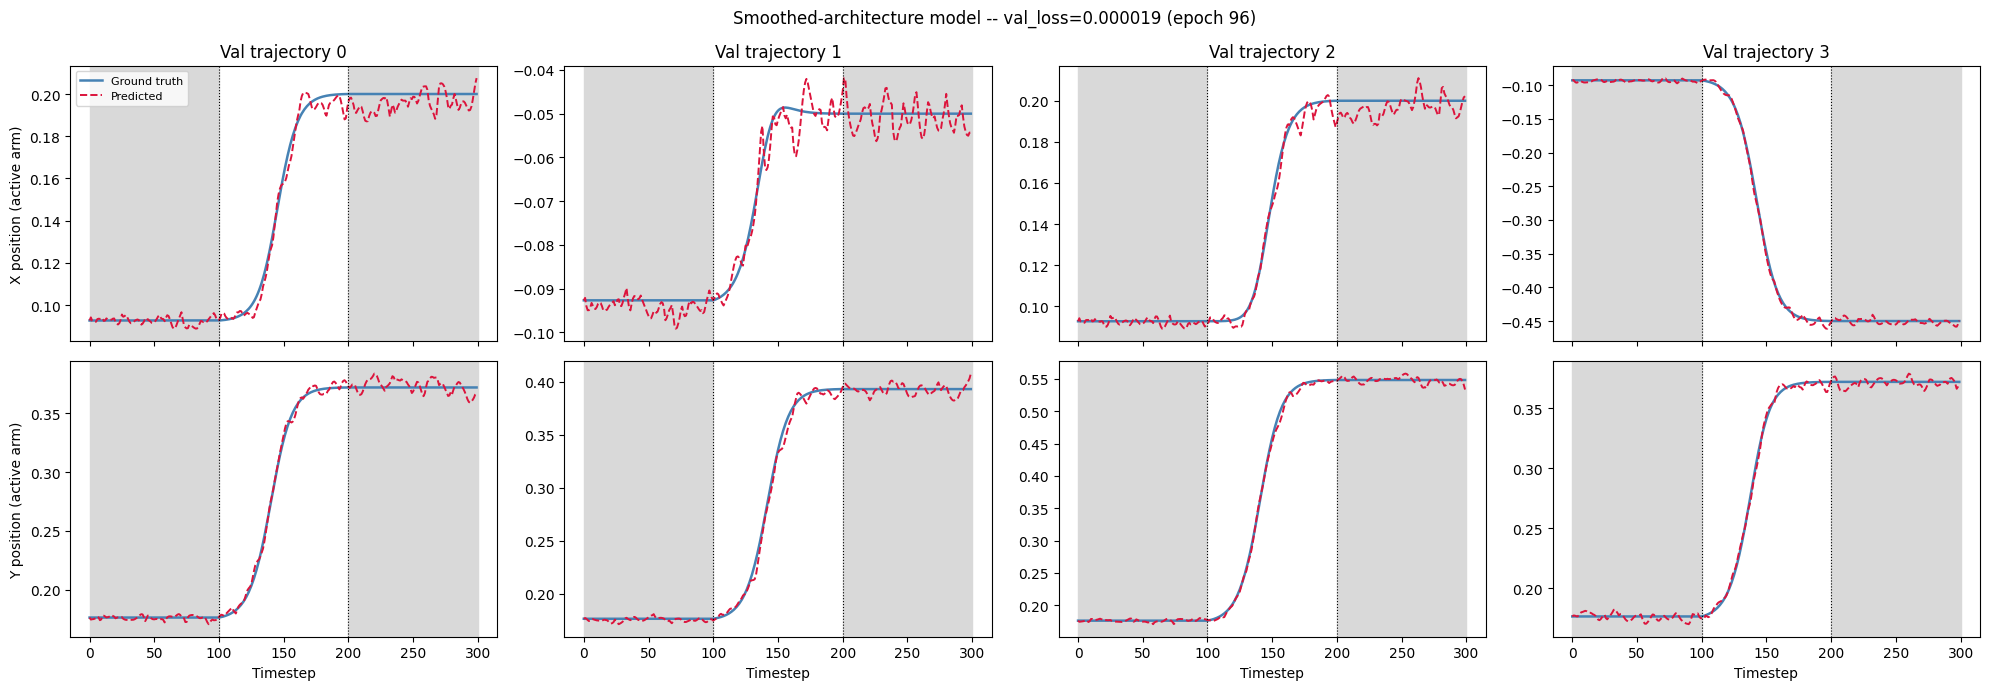

traj | rest-pre |x_err| |  motion mean err | rest-post |x_err|
   0 |          0.00140 |          0.00508 |           0.00535
   1 |          0.00181 |          0.00576 |           0.00288
   2 |          0.00116 |          0.00516 |           0.00496
   3 |          0.00163 |          0.00473 |           0.00319


In [4]:
N_SHOW = 4

fig, axes = plt.subplots(2, N_SHOW, figsize=(5 * N_SHOW, 7), sharex=True)
pad_pre, pad_post = dataset.pad_pre, dataset.pad_post
region_stats = []

for i in range(N_SHOW):
    traj_gt, target, moving_flag, _ = val_dataset[i]
    gt_traj = traj_gt.numpy()
    pred_traj = autoregressive_rollout(model, traj_gt, target, moving_flag, device)
    cols = active_cols(gt_traj)
    mflag = moving_flag.numpy(); T = len(mflag)
    move_start = pad_pre; move_end = pad_pre + int(mflag.sum())

    for row, (label, coord_idx) in enumerate([("X position (active arm)", 0), ("Y position (active arm)", 1)]):
        ax = axes[row, i]
        ax.axvspan(0, move_start, color="0.85", zorder=0); ax.axvspan(move_end, T, color="0.85", zorder=0)
        ax.plot(gt_traj[:, cols][:, coord_idx], color="steelblue", lw=1.8, label="Ground truth")
        ax.plot(pred_traj[:, cols][:, coord_idx], color="crimson", lw=1.4, ls="--", label="Predicted")
        ax.axvline(move_start, color="black", lw=0.8, ls=":"); ax.axvline(move_end, color="black", lw=0.8, ls=":")
        if row == 0: ax.set_title(f"Val trajectory {i}")
        if i == 0: ax.set_ylabel(label)
        if row == 1: ax.set_xlabel("Timestep")
        if i == 0 and row == 0: ax.legend(fontsize=8, loc="upper left")

    rest_pre_err = np.abs(pred_traj[1:move_start, cols][:, 0] - gt_traj[1:move_start, cols][:, 0]).mean()
    rest_post_err = np.abs(pred_traj[move_end:, cols][:, 0] - gt_traj[move_end:, cols][:, 0]).mean()
    motion_err = np.linalg.norm(pred_traj[move_start:move_end, cols] - gt_traj[move_start:move_end, cols], axis=1).mean()
    region_stats.append((i, rest_pre_err, motion_err, rest_post_err))

plt.suptitle(f"Smoothed-architecture model -- val_loss={ckpt['val_loss']:.6f} (epoch {ckpt['epoch']})")
plt.tight_layout()
plt.show()

print(f"{'traj':>4} | {'rest-pre |x_err|':>16} | {'motion mean err':>16} | {'rest-post |x_err|':>17}")
for row in region_stats:
    print(f"{row[0]:>4} | {row[1]:>16.5f} | {row[2]:>16.5f} | {row[3]:>17.5f}")

## Reading the results

- **Rest-pre / rest-post error**: how far the model's prediction drifts
  from a stationary hand during the resting periods before/after the
  reach (should be small — nothing should be moving).
- **Motion error**: mean position error while the arm is actually
  reaching (naturally larger, since this is the hard part).

Since this is an **autoregressive** rollout (the model only sees its own
past predictions, never the ground truth, after the first timestep),
small errors don't get corrected and can accumulate over the trajectory
— that's expected and is part of what makes this a meaningful test of
the trained weights.